In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout

# List of file paths to your CSV files
file_paths = ["dehradun 2015-01-01 to 2015-12-31.csv",
              "dehradun 2016-01-01 to 2017-12-31.csv"
              "dehradun 2018-01-01 to 2019-12-31.csv"
              "dehradun 2020-01-01 to 2021-12-31.csv"
              "dehradun 2022-01-01 to 2023-12-31.csv"
              ]

# Initialize an empty list to store the dataframes
dfs = []

# Loop through each file and read it into a DataFrame
for file in file_paths:
    df = pd.read_csv(file)
    dfs.append(df)

# Concatenate all the DataFrames into a single DataFrame
full_data = pd.concat(dfs, ignore_index=True)

# Convert 'datetime' column to datetime type if it's not already
full_data['datetime'] = pd.to_datetime(full_data['datetime'])

# Sort the data by the 'datetime' column
full_data = full_data.sort_values(by='datetime')

# save the csv
# full_data.to_csv('edited_weather_data.csv', index=False)

full_data = full_data.drop(['name', 'feelslikemax', "feelslikemin", "precipcover", "preciptype", "solarenergy", "uvindex", "severerisk", "sunrise", "sunset", "moonphase", "conditions", "description", "icon","stations", "snow", "snowdepth", "solarradiation"], axis=1)



import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Assuming you have loaded your full_data DataFrame

# 1. Display descriptive statistics
print(full_data.describe())

# 2. Convert 'datetime' to datetime object
full_data['datetime'] = pd.to_datetime(full_data['datetime'])

# 3. Check for missing values
print(full_data.isnull().sum())

# 4. Fill missing values or drop rows/columns as needed
full_data.fillna(method='ffill', inplace=True)  # Example of forward filling

# Ensure any missing values in visibility are handled
full_data['visibility'].fillna(full_data['visibility'].mean(), inplace=True)  # Replace with mean or other methods

# 5. Encode 'precipprob' to binary
full_data['precipprob'] = full_data['precipprob'].apply(lambda x: 1 if x == 100 else 0)

# 6. Normalize 'temp' using MinMaxScaler
temp_scaler = MinMaxScaler()
full_data[['temp']] = temp_scaler.fit_transform(full_data[['temp']])

# 7. Normalize other features using MinMaxScaler
scaler = MinMaxScaler()
full_data[['temp', 'tempmax', 'tempmin', 'feelslike', 'dew', 'humidity',
           'precip', 'precipprob', 'windgust', 'windspeed',
           'sealevelpressure', 'cloudcover', 'visibility']] = scaler.fit_transform(
               full_data[['temp', 'tempmax', 'tempmin', 'feelslike', 'dew',
                           'humidity', 'precip', 'precipprob',
                           'windgust', 'windspeed', 'sealevelpressure',
                           'cloudcover', 'visibility']])

# 8. Normalize wind direction
full_data['winddir_rad'] = np.deg2rad(full_data['winddir'])  # Convert to radians
full_data['winddir_sin'] = np.sin(full_data['winddir_rad'])  # Sine transformation
full_data['winddir_cos'] = np.cos(full_data['winddir_rad'])  # Cosine transformation

# 9. Drop the original winddir column if no longer needed
full_data.drop('winddir', axis=1, inplace=True)

# 10. Drop the 'datetime' column if it exists in your data
full_data = full_data.drop(['datetime'], axis=1)

# 11. Display descriptive statistics for the normalized data
print(full_data[['temp', 'tempmax', 'tempmin', 'windspeed']].describe())

ModuleNotFoundError: No module named 'keras'

In [ ]:
import numpy as np

# Function to create sequences
def create_sequences(data, target_column, time_steps):
    sequences = []
    targets = []

    for i in range(len(data) - time_steps):
        seq = data.iloc[i:i + time_steps].values  # Create sequence
        target = data.iloc[i + time_steps][target_column]  # Target value
        sequences.append(seq)
        targets.append(target)

    return np.array(sequences), np.array(targets)

# Define your target variable and time steps
target_column = 'temp'  # Change this if you want to predict a different variable
time_steps = 11  # Adjust this according to your needs

# Create sequences
X, y = create_sequences(full_data, target_column, time_steps)

# Print the shape of the sequences
print("Shape of X:", X.shape)  # (number_of_samples, time_steps, number_of_features)
print("Shape of y:", y.shape)  # (number_of_samples,)


Shape of X: (3276, 11, 16)
Shape of y: (3276,)


In [ ]:

from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Further split training into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, shuffle=False)

print("Training set shape:", X_train.shape, y_train.shape)
print("Validation set shape:", X_val.shape, y_val.shape)
print("Test set shape:", X_test.shape, y_test.shape)


Training set shape: (2096, 11, 16) (2096,)
Validation set shape: (524, 11, 16) (524,)
Test set shape: (656, 11, 16) (656,)


In [ ]:
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout


# Define the LSTM model G (batch 16)
# model = Sequential()
# model.add(LSTM(100, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
# model.add(Dropout(0.2))
# model.add(LSTM(150))
# model.add(Dropout(0.2))
# model.add(Dense(1))  # Output layer for regression

# Define the LSTM model J (batch 16) batch 20 epochs 85 window 12
# model = Sequential()
# model.add(LSTM(90, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
# model.add(Dropout(0.2))
# model.add(LSTM(150))
# model.add(Dropout(0.2))
# model.add(Dense(1))  # Output layer for regression

# # Define the LSTM model H (batch 16) I window=12
# model = Sequential()
# model.add(LSTM(80, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
# model.add(Dropout(0.2))
# model.add(LSTM(150))
# model.add(Dropout(0.2))
# model.add(Dense(1))  # Output layer for regression

# Define the LSTM model K (batch 32)
model = Sequential()
model.add(LSTM(90, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))
model.add(LSTM(150))
model.add(Dropout(0.2))
model.add(Dense(1))  # Output layer for regression

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Display the model summary
model.summary()
# Best Hyperparameters: {'lstm_units': 150, 'epochs': 100, 'dropout_rate': 0.3, 'batch_size': 16}
# Best Hyperparameters: {'lstm_units': 100, 'epochs': 100, 'dropout_rate': 0.1, 'batch_size': 32}
# Best Hyperparameters: {'lstm_units': 150, 'epochs': 100, 'dropout_rate': 0.2, 'batch_size': 32}
# Best Hyperparameters: {'lstm_units': 100, 'epochs': 100, 'dropout_rate': 0.2, 'batch_size': 16}
# Best Hyperparameters: {'lstm_units': 80, 'epochs': 80, 'dropout_rate': 0.2, 'batch_size': 16}
# Best Hyperparameters: {'lstm_units': 100, 'epochs': 100, 'dropout_rate': 0.2, 'batch_size': 24}


C:\Users\ayush\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_68"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_136 (LSTM)                      │ (None, 11, 90)              │          38,520 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_136 (Dropout)                │ (None, 11, 90)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_137 (LSTM)                      │ (None, 150)                 │         144,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_137 (Dropout)                │ (None, 150)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_68 (Dense)                     │ (None, 1)                   │             151 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 183,271 (715.90 KB)

 Trainable params: 183,271 (715.90 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/85
105/105 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0360 - val_loss: 0.0041
Epoch 2/85
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0054 - val_loss: 0.0037
Epoch 3/85
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0054 - val_loss: 0.0033
Epoch 4/85
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0045 - val_loss: 0.0031
Epoch 5/85
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0041 - val_loss: 0.0031
Epoch 6/85
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0043 - val_loss: 0.0031
Epoch 7/85
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0038 - val_loss: 0.0033
Epoch 8/85
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0038 - val_loss: 0.0029
Epoch 9/85
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0032 - val_loss: 0.0029
Epoch 10/85
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0043 - val_loss: 0.0025
Epoch 11/85
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0034 - val_loss: 0.0024
Epoch 12/85
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/ste

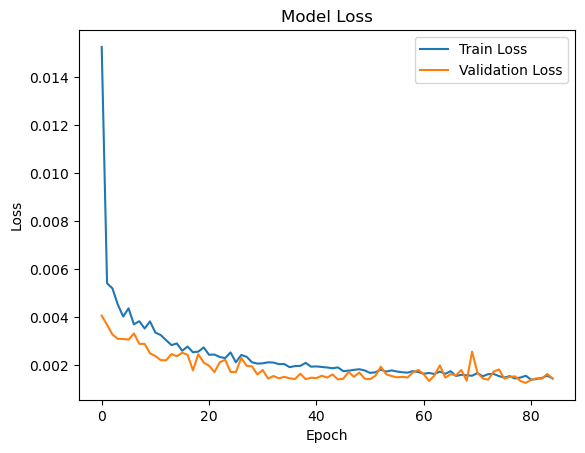

In [ ]:
# Train the model
history = model.fit(X_train, y_train, epochs=85, batch_size=20, validation_data=(X_val, y_val))

# Plot training & validation loss
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()


21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0044
Test Loss: 0.004437783733010292
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
Evaluation Metrics:
Mean Absolute Error (MAE): 1.5400371397413861
Mean Squared Error (MSE): 3.3560747952776957
Root Mean Squared Error (RMSE): 1.8319592777345504
R-squared (R²): 0.8899817765571199
Mean Bias Deviation (MBD): 6.874773475313366%


E:\conda\Lib\site-packages\sklearn\metrics\_regression.py:483: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


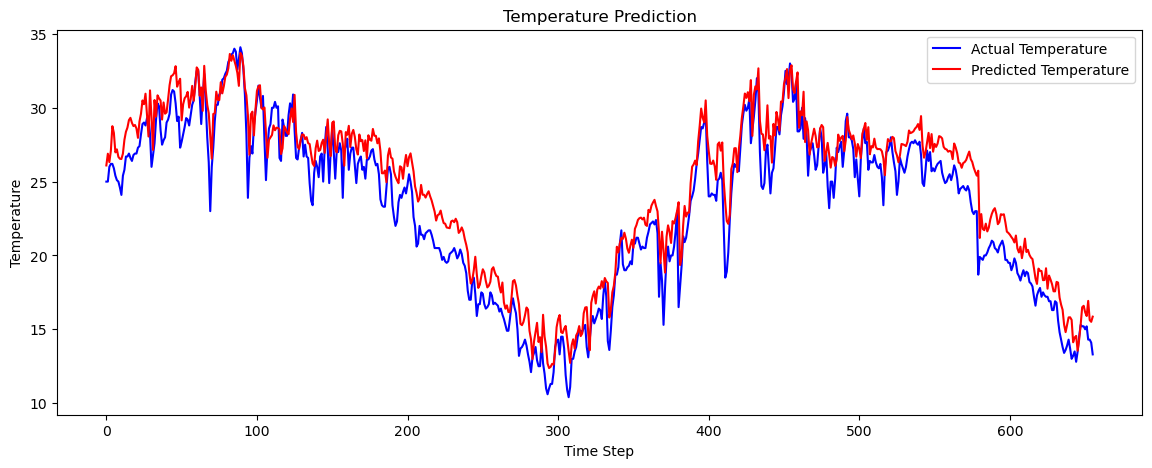

In [ ]:
# Evaluate the model on the test set
test_loss = model.evaluate(X_test, y_test)
print(f'Test Loss: {test_loss}')

# Make predictions
predictions = model.predict(X_test)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Inverse transform predictions and true values using the temp_scaler
predictions_original = temp_scaler.inverse_transform(predictions)  # No need to reshape
y_test_original = temp_scaler.inverse_transform(y_test.reshape(-1, 1))  # Reshape if necessary

# Import necessary libraries
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Calculate evaluation metrics
mae = mean_absolute_error(y_test_original, predictions_original)
mse = mean_squared_error(y_test_original, predictions_original)
rmse = mean_squared_error(y_test_original, predictions_original, squared=False)
r_squared = r2_score(y_test_original, predictions_original)
mbd = np.mean((predictions_original - y_test_original) / y_test_original) * 100

# Print the evaluation results
print("Evaluation Metrics:")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R-squared (R²): {r_squared}")
print(f"Mean Bias Deviation (MBD): {mbd}%")

# Plot predictions vs actual
plt.figure(figsize=(14, 5))
plt.plot(y_test_original, label='Actual Temperature', color='blue')  # Actual temperatures
plt.plot(predictions_original, label='Predicted Temperature', color='red')  # Predicted temperatures
plt.title('Temperature Prediction')
plt.xlabel('Time Step')
plt.ylabel('Temperature')
plt.legend()
plt.show()



In [ ]:
# Save the trained model
model.save('best_weather_model.h5')  # Save as an h5 file

C:\Users\ayush\AppData\Local\Temp\ipykernel_3344\1987122052.py:30: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  unseen_data.fillna(method='ffill', inplace=True)
C:\Users\ayush\AppData\Local\Temp\ipykernel_3344\1987122052.py:31: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  unseen_data['visibility'].fillna(unseen_data['visibility'].mean(), inplace=True)


datetime            0
tempmax             0
tempmin             0
temp                0
feelslike           0
dew                 0
humidity            0
precip              0
precipprob          0
windgust            0
windspeed           0
winddir             0
sealevelpressure    0
cloudcover          0
visibility          0
dtype: int64
Shape of X_unseen: (19, 12, 16)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step
Mean Absolute Error (MAE): 0.6317366549843233
Mean Squared Error (MSE): 0.7438870529269814
Root Mean Squared Error (RMSE): 0.8624888711902209
R-squared (R²): 0.2625275275810385
Mean Bias Deviation (MBD): 2.277913521123856%


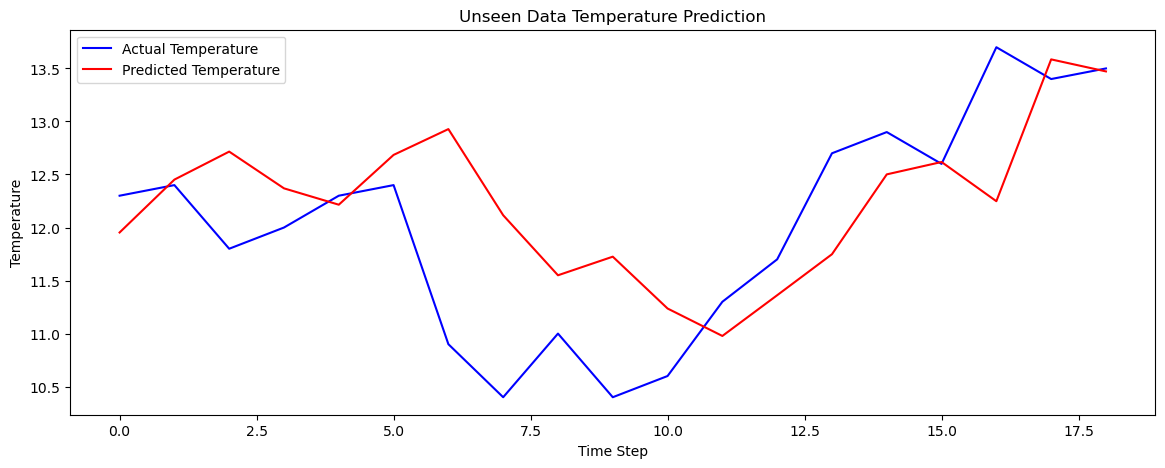

Differences between predicted and actual temperatures (Predicted - Actual):
[-0.34677486  0.05174026  0.91577454  0.36940479 -0.08482628  0.2846714
  2.02803288  1.71593151  0.54982567  1.32517204  0.63640251 -0.32232456
 -0.33834953 -0.95172043 -0.39885654  0.01781216 -1.45195503  0.18530903
 -0.02811241]


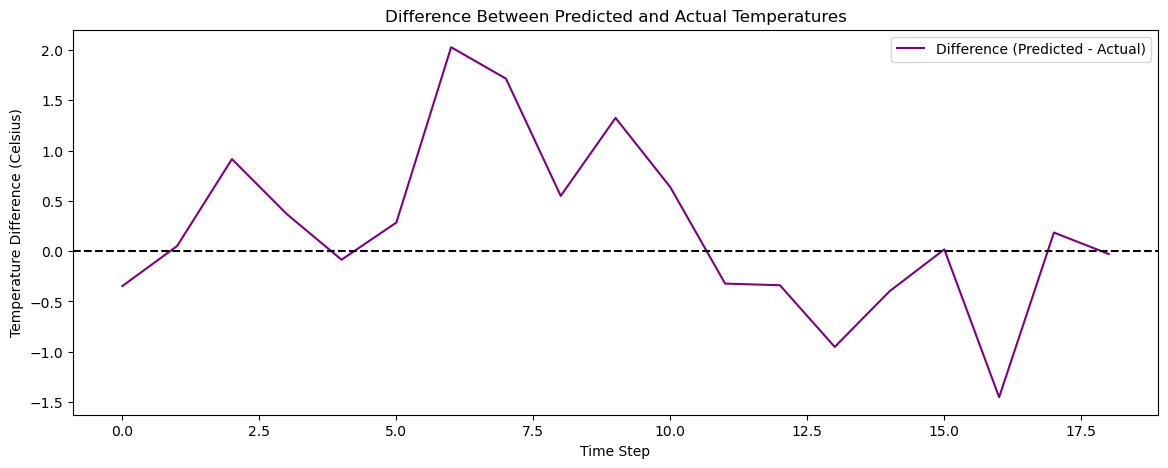

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from keras.models import load_model

# Load unseen data
unseen_file_path = 'E:\\project_work\\dehradun 2024-01-01 to 2024-01-31.csv'  # Replace with the actual file path
unseen_data = pd.read_csv(unseen_file_path)

# Initialize an empty list to store the DataFrames
dfs_unseen = []

# Convert 'datetime' column to datetime type if it's not already
unseen_data['datetime'] = pd.to_datetime(unseen_data['datetime'])

# Sort the data by the 'datetime' column
unseen_data = unseen_data.sort_values(by='datetime')

# Drop unnecessary columns (ensure these columns exist in the unseen data)
unseen_data = unseen_data.drop(['name', 'feelslikemax', "feelslikemin", "precipcover", "preciptype",
                                 "solarenergy", "uvindex", "severerisk", "sunrise", "sunset",
                                 "moonphase", "conditions", "description", "icon", "stations",
                                 "snow", "snowdepth", "solarradiation"], axis=1, errors='ignore')

# Check for missing values
print(unseen_data.isnull().sum())

# Fill missing values
unseen_data.fillna(method='ffill', inplace=True)
unseen_data['visibility'].fillna(unseen_data['visibility'].mean(), inplace=True)

# Encode 'precipprob' to binary
unseen_data['precipprob'] = unseen_data['precipprob'].apply(lambda x: 1 if x == 100 else 0)

# Normalize 'temp' using MinMaxScaler
temp_scaler = MinMaxScaler()
unseen_data[['temp']] = temp_scaler.fit_transform(unseen_data[['temp']])

# Normalize other features using MinMaxScaler
scaler = MinMaxScaler()
unseen_data[['temp', 'tempmax', 'tempmin', 'feelslike', 'dew', 'humidity',
             'precip', 'precipprob', 'windgust', 'windspeed',
             'sealevelpressure', 'cloudcover', 'visibility']] = scaler.fit_transform(
                 unseen_data[['temp', 'tempmax', 'tempmin', 'feelslike', 'dew',
                               'humidity', 'precip', 'precipprob',
                               'windgust', 'windspeed', 'sealevelpressure',
                               'cloudcover', 'visibility']])

# Normalize wind direction
unseen_data['winddir_rad'] = np.deg2rad(unseen_data['winddir'])  # Convert to radians
unseen_data['winddir_sin'] = np.sin(unseen_data['winddir_rad'])  # Sine transformation
unseen_data['winddir_cos'] = np.cos(unseen_data['winddir_rad'])  # Cosine transformation

# Drop the original winddir column if no longer needed
unseen_data.drop('winddir', axis=1, inplace=True)

# Drop the 'datetime' column if it exists in your data
unseen_data = unseen_data.drop(['datetime'], axis=1, errors='ignore')

# Prepare data for model prediction
window_size = 12  # Your previous window size
X_unseen, y_unseen = [], []

for i in range(window_size, len(unseen_data)):
    X_unseen.append(unseen_data.iloc[i-window_size:i].values)
    y_unseen.append(unseen_data.iloc[i]['temp'])  # Assuming 'temp' is the target variable

X_unseen, y_unseen = np.array(X_unseen), np.array(y_unseen)

# Check the shape of X_unseen
print(f"Shape of X_unseen: {X_unseen.shape}")  # Should be (samples, window_size, features)

# Load the trained model
model = load_model('C:\\Users\\ayush\\Downloads\\best_weather_model.h5')  # Replace with your model path

# Ensure the input shape matches the model's expected shape
# Make predictions
predictions = model.predict(X_unseen)

# Inverse transform predictions and actual values for comparison
predictions_inv = temp_scaler.inverse_transform(predictions)
y_unseen_inv = temp_scaler.inverse_transform(y_unseen.reshape(-1, 1))

# Calculate evaluation metrics
mae = np.mean(np.abs(predictions_inv - y_unseen_inv))
mse = np.mean((predictions_inv - y_unseen_inv)**2)
rmse = np.sqrt(mse)
r_squared = 1 - (np.sum((predictions_inv - y_unseen_inv) ** 2) / np.sum((y_unseen_inv - np.mean(y_unseen_inv)) ** 2))

# Calculate Mean Bias Deviation (MBD)
mbd = np.mean((predictions_inv - y_unseen_inv) / y_unseen_inv) * 100

# Print the evaluation results
print(f'Mean Absolute Error (MAE): {mae}')
print(f'Mean Squared Error (MSE): {mse}')
print(f'Root Mean Squared Error (RMSE): {rmse}')
print(f'R-squared (R²): {r_squared}')
print(f'Mean Bias Deviation (MBD): {mbd}%')

# Plot predictions vs actual
plt.figure(figsize=(14, 5))
plt.plot(y_unseen_inv, label='Actual Temperature', color='blue')
plt.plot(predictions_inv, label='Predicted Temperature', color='red')
plt.title('Unseen Data Temperature Prediction')
plt.xlabel('Time Step')
plt.ylabel('Temperature')
plt.legend()
plt.show()


# Calculate the difference between predicted and actual temperatures
temperature_diff = predictions_inv.flatten() - y_unseen_inv.flatten()

# Print the differences
print("Differences between predicted and actual temperatures (Predicted - Actual):")
print(temperature_diff)

# Optionally, plot the differences to visualize the variations
plt.figure(figsize=(14, 5))
plt.plot(temperature_diff, label='Difference (Predicted - Actual)', color='purple')
plt.title('Difference Between Predicted and Actual Temperatures')
plt.xlabel('Time Step')
plt.ylabel('Temperature Difference (Celsius)')
plt.axhline(0, color='black', linestyle='--')  # Add a horizontal line at y=0 for reference
plt.legend()
plt.show()


# **Model** **Training**

In [ ]:
from tensorflow.keras.models import load_model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt

# Load the models from .h5 files
model_H = load_model('/content/model_h.h5')  # Replace with your actual model file name
model_D = load_model('/content/model_d.h5')  # Replace with your actual model file name
model_G = load_model('/content/model_g.h5')  # Replace with your actual model file name

# Define the evaluation function
def evaluate_model(model, X_test, y_test, temp_scaler):
    # Evaluate the model on the test set
    test_loss = model.evaluate(X_test, y_test)
    print(f'Test Loss: {test_loss}')

    # Make predictions
    predictions = model.predict(X_test)

    # Inverse transform predictions and true values using the temp_scaler
    predictions_original = temp_scaler.inverse_transform(predictions)  # No need to reshape
    y_test_original = temp_scaler.inverse_transform(y_test.reshape(-1, 1))  # Reshape if necessary

    # Calculate evaluation metrics
    mae = mean_absolute_error(y_test_original, predictions_original)
    mse = mean_squared_error(y_test_original, predictions_original)
    rmse = mean_squared_error(y_test_original, predictions_original, squared=False)
    r_squared = r2_score(y_test_original, predictions_original)
    mbd = np.mean((predictions_original - y_test_original) / y_test_original) * 100

    # Print the evaluation results
    print("Evaluation Metrics:")
    print(f"Mean Absolute Error (MAE): {mae}")
    print(f"Mean Squared Error (MSE): {mse}")
    print(f"Root Mean Squared Error (RMSE): {rmse}")
    print(f"R-squared (R²): {r_squared}")
    print(f"Mean Bias Deviation (MBD): {mbd}%")

    # Plot predictions vs actual
    plt.figure(figsize=(14, 5))
    plt.plot(y_test_original, label='Actual Temperature', color='blue')  # Actual temperatures
    plt.plot(predictions_original, label='Predicted Temperature', color='red')  # Predicted temperatures
    plt.title('Temperature Prediction')
    plt.xlabel('Time Step')
    plt.ylabel('Temperature')
    plt.legend()
    plt.show()

# Call the function for Model H
print("Model H Evaluation:")
evaluate_model(model_H, X_test, y_test, temp_scaler)

# Call the function for Model D
print("Model D Evaluation:")
evaluate_model(model_D, X_test, y_test, temp_scaler)

# Call the function for Model G
print("Model G Evaluation:")
evaluate_model(model_G, X_test, y_test, temp_scaler)

**Unseen data **

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from keras.models import load_model

# Load unseen data
unseen_file_path = '/content/drive/MyDrive/dehradun 2024-01-01 to 2024-01-31.csv'  # Replace with the actual file path
unseen_data = pd.read_csv(unseen_file_path)

# Convert 'datetime' column to datetime type
unseen_data['datetime'] = pd.to_datetime(unseen_data['datetime'])
# Sort the data by the 'datetime' column
unseen_data = unseen_data.sort_values(by='datetime')

# Drop unnecessary columns
unseen_data = unseen_data.drop(['name', 'feelslikemax', "feelslikemin", "precipcover", "preciptype",
                                 "solarenergy", "uvindex", "severerisk", "sunrise", "sunset",
                                 "moonphase", "conditions", "description", "icon", "stations",
                                 "snow", "snowdepth", "solarradiation"], axis=1, errors='ignore')

# Check for missing values
print(unseen_data.isnull().sum())

# Fill missing values
unseen_data.fillna(method='ffill', inplace=True)
unseen_data['visibility'].fillna(unseen_data['visibility'].mean(), inplace=True)

# Encode 'precipprob' to binary
unseen_data['precipprob'] = unseen_data['precipprob'].apply(lambda x: 1 if x == 100 else 0)

# Normalize 'temp' using MinMaxScaler
temp_scaler = MinMaxScaler()
unseen_data[['temp']] = temp_scaler.fit_transform(unseen_data[['temp']])

# Normalize other features using MinMaxScaler
scaler = MinMaxScaler()
unseen_data[['temp', 'tempmax', 'tempmin', 'feelslike', 'dew', 'humidity',
             'precip', 'precipprob', 'windgust', 'windspeed',
             'sealevelpressure', 'cloudcover', 'visibility']] = scaler.fit_transform(
                 unseen_data[['temp', 'tempmax', 'tempmin', 'feelslike', 'dew',
                               'humidity', 'precip', 'precipprob',
                               'windgust', 'windspeed', 'sealevelpressure',
                               'cloudcover', 'visibility']])

# Normalize wind direction
unseen_data['winddir_rad'] = np.deg2rad(unseen_data['winddir'])  # Convert to radians
unseen_data['winddir_sin'] = np.sin(unseen_data['winddir_rad'])  # Sine transformation
unseen_data['winddir_cos'] = np.cos(unseen_data['winddir_rad'])  # Cosine transformation

# Drop the original winddir column
unseen_data.drop('winddir', axis=1, inplace=True)

# Drop the 'datetime' column if it exists in your data
unseen_data = unseen_data.drop(['datetime'], axis=1, errors='ignore')

# Prepare data for model prediction
window_size = 10  # Your previous window size
X_unseen, y_unseen = [], []

for i in range(window_size, len(unseen_data)):
    X_unseen.append(unseen_data.iloc[i-window_size:i].values)
    y_unseen.append(unseen_data.iloc[i]['temp'])  # Assuming 'temp' is the target variable

X_unseen, y_unseen = np.array(X_unseen), np.array(y_unseen)

# Load the trained models
model_H = load_model('/content/model_h.h5')  # Replace with your model path
model_D = load_model('/content/model_d.h5')  # Replace with your model path
model_G = load_model('/content/model_g.h5')  # Replace with your actual model file name

# Function to evaluate the model on unseen data
def evaluate_unseen_data(model, X_unseen, y_unseen, temp_scaler):
    # Make predictions
    predictions = model.predict(X_unseen)

    # Inverse transform predictions and actual values
    predictions_inv = temp_scaler.inverse_transform(predictions)
    y_unseen_inv = temp_scaler.inverse_transform(y_unseen.reshape(-1, 1))

    # Calculate evaluation metrics
    mae = np.mean(np.abs(predictions_inv - y_unseen_inv))
    mse = np.mean((predictions_inv - y_unseen_inv) ** 2)
    rmse = np.sqrt(mse)
    r_squared = 1 - (np.sum((predictions_inv - y_unseen_inv) ** 2) / np.sum((y_unseen_inv - np.mean(y_unseen_inv)) ** 2))
    mbd = np.mean((predictions_inv - y_unseen_inv) / y_unseen_inv) * 100

    # Print the evaluation results
    print("Evaluation Metrics:")
    print(f"Mean Absolute Error (MAE): {mae}")
    print(f"Mean Squared Error (MSE): {mse}")
    print(f"Root Mean Squared Error (RMSE): {rmse}")
    print(f"R-squared (R²): {r_squared}")
    print(f"Mean Bias Deviation (MBD): {mbd}%")

    # Plot predictions vs actual
    plt.figure(figsize=(14, 5))
    plt.plot(y_unseen_inv, label='Actual Temperature', color='blue')
    plt.plot(predictions_inv, label='Predicted Temperature', color='red')
    plt.title('Unseen Data Temperature Prediction')
    plt.xlabel('Time Step')
    plt.ylabel('Temperature')
    plt.legend()
    plt.show()

    # Calculate and plot the difference between predicted and actual temperatures
    temperature_diff = predictions_inv.flatten() - y_unseen_inv.flatten()
    plt.figure(figsize=(14, 5))
    plt.plot(temperature_diff, label='Difference (Predicted - Actual)', color='purple')
    plt.title('Difference Between Predicted and Actual Temperatures')
    plt.xlabel('Time Step')
    plt.ylabel('Temperature Difference (Celsius)')
    plt.axhline(0, color='black', linestyle='--')  # Add a horizontal line at y=0 for reference
    plt.legend()
    plt.show()

# Call the function for Model H
print("Model H Evaluation on Unseen Data:")
evaluate_unseen_data(model_H, X_unseen, y_unseen, temp_scaler)  # Use temp_scaler for temperature

# Call the function for Model D
print("Model D Evaluation on Unseen Data:")
evaluate_unseen_data(model_D, X_unseen, y_unseen, temp_scaler)  # Use temp_scaler for temperature

# Call the function for Model G
print("Model G Evaluation on Unseen Data:")
evaluate_unseen_data(model_G, X_unseen, y_unseen, temp_scaler)  # Use temp_scaler for temperature


In [ ]:
from keras.models import load_model

model = load_model('/content/model_d.h5')
model.summary()
# Get model configuration
config = model.get_config()

# Print the configuration
print(config)


# **Model** **Tuning**

In [ ]:
# tuning
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.base import BaseEstimator, RegressorMixin

# Custom Keras Regressor Class
class KerasRegressor(BaseEstimator, RegressorMixin):
    def __init__(self, lstm_units=100, dropout_rate=0.2, learning_rate=0.001, batch_size=32, epochs=100):
        self.lstm_units = lstm_units
        self.dropout_rate = dropout_rate
        self.learning_rate = learning_rate
        self.batch_size = batch_size
        self.epochs = epochs
        self.model = None

    def create_model(self):
        model = Sequential()
        model.add(LSTM(self.lstm_units, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
        model.add(Dropout(self.dropout_rate))
        model.add(LSTM(150))
        model.add(Dropout(0.2))
        model.add(Dense(1))  # Output layer for regression
        model.compile(optimizer=Adam(learning_rate=self.learning_rate), loss='mean_squared_error')
        return model

    def fit(self, X, y):
        self.model = self.create_model()
        self.model.fit(X, y, epochs=self.epochs, batch_size=self.batch_size, verbose=0)

    def predict(self, X):
        return self.model.predict(X)

    def score(self, X, y):
        return -self.model.evaluate(X, y, verbose=0)  # Negative because we want to minimize the loss

# Define hyperparameters to search
param_dist = {
    'lstm_units': [60, 80, 100, 150],
    'dropout_rate': [0.1, 0.2, 0.3],
    'batch_size': [16, 24, 32],
    'epochs': [50, 80, 100]  # You can adjust the number of epochs to search over
}

# Create a RandomizedSearchCV object
random_search = RandomizedSearchCV(estimator=KerasRegressor(), param_distributions=param_dist, n_iter=10, scoring='neg_mean_squared_error', cv=3, verbose=1)

# Fit the RandomizedSearchCV
random_search.fit(X_train, y_train)

# Display the best hyperparameters and corresponding score
print("Best Hyperparameters:", random_search.best_params_)
print("Best Score:", random_search.best_score_)


Fitting 3 folds for each of 10 candidates, totalling 30 fits


C:\Users\ayush\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step


C:\Users\ayush\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step


...

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step


C:\Users\ayush\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step


C:\Users\ayush\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Best Hyperparameters: {'lstm_units': 100, 'epochs': 100, 'dropout_rate': 0.2, 'batch_size': 24}
Best Score: -0.0015355372600169461


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import KFold
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout

# Load and preprocess the data
file_paths = [
    '/content/drive/MyDrive/dehradun 2015-01-01 to 2015-12-31.csv',
    '/content/drive/MyDrive/dehradun 2016-01-01 to 2017-12-31.csv',
    '/content/drive/MyDrive/dehradun 2018-01-01 to 2019-12-31.csv',
    '/content/drive/MyDrive/dehradun 2020-01-01 to 2021-12-31.csv',
    '/content/drive/MyDrive/dehradun 2022-01-01 to 2023-12-31.csv'
]

# Initialize an empty list to store the dataframes
dfs = []

# Loop through each file and read it into a DataFrame
for file in file_paths:
    df = pd.read_csv(file)
    dfs.append(df)

# Concatenate all the DataFrames into a single DataFrame
full_data = pd.concat(dfs, ignore_index=True)

# Convert 'datetime' column to datetime type if it's not already
full_data['datetime'] = pd.to_datetime(full_data['datetime'])

# Sort the data by the 'datetime' column
full_data = full_data.sort_values(by='datetime')

# Drop unnecessary columns
full_data = full_data.drop(['name', 'feelslikemax', "feelslikemin", "precipcover",
                             "preciptype", "solarenergy", "uvindex", "severerisk",
                             "sunrise", "sunset", "moonphase", "conditions",
                             "description", "icon", "stations", "snow",
                             "snowdepth", "solarradiation"], axis=1)

# Fill missing values
full_data.fillna(method='ffill', inplace=True)
full_data['visibility'].fillna(full_data['visibility'].mean(), inplace=True)

# Encode 'precipprob' to binary
full_data['precipprob'] = full_data['precipprob'].apply(lambda x: 1 if x == 100 else 0)

# Normalize features
scaler = MinMaxScaler()
full_data[['temp', 'tempmax', 'tempmin', 'feelslike', 'dew', 'humidity',
           'precip', 'precipprob', 'windgust', 'windspeed',
           'sealevelpressure', 'cloudcover', 'visibility']] = scaler.fit_transform(
               full_data[['temp', 'tempmax', 'tempmin', 'feelslike', 'dew',
                           'humidity', 'precip', 'precipprob',
                           'windgust', 'windspeed', 'sealevelpressure',
                           'cloudcover', 'visibility']])

# Normalize wind direction
full_data['winddir_rad'] = np.deg2rad(full_data['winddir'])  # Convert to radians
full_data['winddir_sin'] = np.sin(full_data['winddir_rad'])  # Sine transformation
full_data['winddir_cos'] = np.cos(full_data['winddir_rad'])  # Cosine transformation

# Drop the original winddir column if no longer needed
full_data.drop('winddir', axis=1, inplace=True)

# Drop the 'datetime' column if it exists in your data
full_data = full_data.drop(['datetime'], axis=1)

# Function to create sequences
def create_sequences(data, target_column, time_steps):
    sequences = []
    targets = []

    for i in range(len(data) - time_steps):
        seq = data.iloc[i:i + time_steps].values  # Create sequence
        target = data.iloc[i + time_steps][target_column]  # Target value
        sequences.append(seq)
        targets.append(target)

    return np.array(sequences), np.array(targets)

# Define your target variable and time steps
target_column = 'temp'  # Change this if you want to predict a different variable
time_steps = 10  # Adjust this according to your needs

# Create sequences
X, y = create_sequences(full_data, target_column, time_steps)

# Set up K-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Store metrics for each fold
mae_scores = []
mse_scores = []
rmse_scores = []
r2_scores = []

for train_index, val_index in kf.split(X):
    X_train, X_val = X[train_index], X[val_index]
    y_train, y_val = y[train_index], y[val_index]

    # Build your model
    model = Sequential()
    model.add(LSTM(100, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dropout(0.2))
    model.add(LSTM(50))
    model.add(Dropout(0.2))
    model.add(Dense(1))  # Output layer for regression

    # Compile the model
    model.compile(optimizer='adam', loss='mean_squared_error')

    # Train the model
    model.fit(X_train, y_train, epochs=100, batch_size=32, verbose=0)

    # Evaluate the model on validation set
    predictions = model.predict(X_val)

    # Calculate metrics
    mae = np.mean(np.abs(predictions - y_val))
    mse = np.mean((predictions - y_val) ** 2)
    rmse = np.sqrt(mse)
    r2 = 1 - (np.sum((y_val - predictions) ** 2) / np.sum((y_val - np.mean(y_val)) ** 2))

    mae_scores.append(mae)
    mse_scores.append(mse)
    rmse_scores.append(rmse)
    r2_scores.append(r2)

# Calculate mean and standard deviation of the metrics
print("Mean Absolute Error (MAE):", np.mean(mae_scores), "±", np.std(mae_scores))
print("Mean Squared Error (MSE):", np.mean(mse_scores), "±", np.std(mse_scores))
print("Root Mean Squared Error (RMSE):", np.mean(rmse_scores), "±", np.std(rmse_scores))
print("R-squared (R²):", np.mean(r2_scores), "±", np.std(r2_scores))


In [ ]:
y_pred = model.predict(X_test)

In [ ]:
# Inverse transform predictions and actual values
y_pred_rescaled = temp_scaler.inverse_transform(y_pred.reshape(-1, 1))
y_test_rescaled = temp_scaler.inverse_transform(y_test.reshape(-1, 1))

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate MAE
mae = mean_absolute_error(y_test_rescaled, y_pred_rescaled)

# Calculate MSE
mse = mean_squared_error(y_test_rescaled, y_pred_rescaled)

# Calculate RMSE
rmse = np.sqrt(mse)

# Calculate R-squared (R²)
r_squared = r2_score(y_test_rescaled, y_pred_rescaled)

# Print the results
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")
print(f"R-squared (R²): {r_squared}")

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(y_test_rescaled, label="Actual Temperature")
plt.plot(y_pred_rescaled, label="Predicted Temperature", linestyle='--')
plt.title("Actual vs Predicted Temperature")
plt.xlabel("Time")
plt.ylabel("Temperature")
plt.legend()
plt.show()

# Preprocessing

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Assuming you have loaded your full_data DataFrame

# 1. Display descriptive statistics
print(full_data.describe())

# 2. Convert 'datetime' to datetime object
full_data['datetime'] = pd.to_datetime(full_data['datetime'])

# 3. Check for missing values
print(full_data.isnull().sum())

# 4. Fill missing values or drop rows/columns as needed
full_data.fillna(method='ffill', inplace=True)  # Example of forward filling

# Ensure any missing values in visibility are handled
full_data['visibility'].fillna(full_data['visibility'].mean(), inplace=True)  # Replace with mean or other methods

# 5. Encode 'precipprob' to binary
full_data['precipprob'] = full_data['precipprob'].apply(lambda x: 1 if x == 100 else 0)

# 6. Normalize 'temp' using MinMaxScaler
temp_scaler = MinMaxScaler()
full_data[['temp']] = temp_scaler.fit_transform(full_data[['temp']])

# 7. Normalize other features using MinMaxScaler
scaler = MinMaxScaler()
full_data[['temp', 'tempmax', 'tempmin', 'feelslike', 'dew', 'humidity',
           'precip', 'precipprob', 'windgust', 'windspeed',
           'sealevelpressure', 'cloudcover', 'visibility']] = scaler.fit_transform(
               full_data[['temp', 'tempmax', 'tempmin', 'feelslike', 'dew',
                           'humidity', 'precip', 'precipprob',
                           'windgust', 'windspeed', 'sealevelpressure',
                           'cloudcover', 'visibility']])

# 8. Normalize wind direction
full_data['winddir_rad'] = np.deg2rad(full_data['winddir'])  # Convert to radians
full_data['winddir_sin'] = np.sin(full_data['winddir_rad'])  # Sine transformation
full_data['winddir_cos'] = np.cos(full_data['winddir_rad'])  # Cosine transformation

# 9. Drop the original winddir column if no longer needed
full_data.drop('winddir', axis=1, inplace=True)

# 10. Drop the 'datetime' column if it exists in your data
full_data = full_data.drop(['datetime'], axis=1)

# 11. Display descriptive statistics for the normalized data
print(full_data[['temp', 'tempmax', 'tempmin', 'windspeed']].describe())

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from keras.models import load_model

# Load unseen data
unseen_file_path = '/content/drive/MyDrive/dehradun 2024-01-01 to 2024-01-31.csv'  # Replace with the actual file path
unseen_data = pd.read_csv(unseen_file_path)

# Initialize an empty list to store the DataFrames
dfs_unseen = []

# Convert 'datetime' column to datetime type if it's not already
unseen_data['datetime'] = pd.to_datetime(unseen_data['datetime'])

# Sort the data by the 'datetime' column
unseen_data = unseen_data.sort_values(by='datetime')

# Drop unnecessary columns (ensure these columns exist in the unseen data)
unseen_data = unseen_data.drop(['name', 'feelslikemax', "feelslikemin", "precipcover", "preciptype",
                                 "solarenergy", "uvindex", "severerisk", "sunrise", "sunset",
                                 "moonphase", "conditions", "description", "icon", "stations",
                                 "snow", "snowdepth", "solarradiation"], axis=1, errors='ignore')

# Check for missing values
print(unseen_data.isnull().sum())

# Fill missing values
unseen_data.fillna(method='ffill', inplace=True)
unseen_data['visibility'].fillna(unseen_data['visibility'].mean(), inplace=True)

# Encode 'precipprob' to binary
unseen_data['precipprob'] = unseen_data['precipprob'].apply(lambda x: 1 if x == 100 else 0)

# Normalize 'temp' using MinMaxScaler
temp_scaler = MinMaxScaler()
unseen_data[['temp']] = temp_scaler.fit_transform(unseen_data[['temp']])

# Normalize other features using MinMaxScaler
scaler = MinMaxScaler()
unseen_data[['temp', 'tempmax', 'tempmin', 'feelslike', 'dew', 'humidity',
             'precip', 'precipprob', 'windgust', 'windspeed',
             'sealevelpressure', 'cloudcover', 'visibility']] = scaler.fit_transform(
                 unseen_data[['temp', 'tempmax', 'tempmin', 'feelslike', 'dew',
                               'humidity', 'precip', 'precipprob',
                               'windgust', 'windspeed', 'sealevelpressure',
                               'cloudcover', 'visibility']])

# Normalize wind direction
unseen_data['winddir_rad'] = np.deg2rad(unseen_data['winddir'])  # Convert to radians
unseen_data['winddir_sin'] = np.sin(unseen_data['winddir_rad'])  # Sine transformation
unseen_data['winddir_cos'] = np.cos(unseen_data['winddir_rad'])  # Cosine transformation

# Drop the original winddir column if no longer needed
unseen_data.drop('winddir', axis=1, inplace=True)

# Drop the 'datetime' column if it exists in your data
unseen_data = unseen_data.drop(['datetime'], axis=1, errors='ignore')

# Prepare data for model prediction
window_size = 10  # Your previous window size
X_unseen, y_unseen = [], []

for i in range(window_size, len(unseen_data)):
    X_unseen.append(unseen_data.iloc[i-window_size:i].values)
    y_unseen.append(unseen_data.iloc[i]['temp'])  # Assuming 'temp' is the target variable

X_unseen, y_unseen = np.array(X_unseen), np.array(y_unseen)

# Load the trained model
model = load_model('/content/best_weather_model.h5')  # Replace with your model path

# Make predictions
predictions = model.predict(X_unseen)

# Inverse transform predictions and actual values for comparison
predictions_inv = temp_scaler.inverse_transform(predictions)
y_unseen_inv = temp_scaler.inverse_transform(y_unseen.reshape(-1, 1))

# Calculate evaluation metrics
mae = np.mean(np.abs(predictions_inv - y_unseen_inv))
mse = np.mean((predictions_inv - y_unseen_inv)**2)
rmse = np.sqrt(mse)
r_squared = 1 - (np.sum((predictions_inv - y_unseen_inv) ** 2) / np.sum((y_unseen_inv - np.mean(y_unseen_inv)) ** 2))

# Calculate Mean Bias Deviation (MBD)
mbd = np.mean((predictions_inv - y_unseen_inv) / y_unseen_inv) * 100

# Print the evaluation results
print(f'Mean Absolute Error (MAE): {mae}')
print(f'Mean Squared Error (MSE): {mse}')
print(f'Root Mean Squared Error (RMSE): {rmse}')
print(f'R-squared (R²): {r_squared}')
print(f'Mean Bias Deviation (MBD): {mbd}%')

# Plot predictions vs actual
plt.figure(figsize=(14, 5))
plt.plot(y_unseen_inv, label='Actual Temperature', color='blue')
plt.plot(predictions_inv, label='Predicted Temperature', color='red')
plt.title('Unseen Data Temperature Prediction')
plt.xlabel('Time Step')
plt.ylabel('Temperature')
plt.legend()
plt.show()